In [1]:
import time
import random
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 12


def is_valid(adjacency, selected, vertex):
    """Можно ли добавить вершину в множество?"""
    return adjacency[vertex].isdisjoint(selected)

def explore(adjacency, total_vertices, current_vertex, selected, best_found):
    """Рекурсивный перебор всех вершин"""
    if current_vertex > total_vertices:
        if len(selected) > len(best_found):
            best_found.clear()
            best_found.update(selected)
        return

    # Ветка 1: НЕ берём вершину
    explore(adjacency, total_vertices, current_vertex + 1, selected, best_found)

    # Ветка 2: БЕРЁМ вершину (если нет конфликта)
    if is_valid(adjacency, selected, current_vertex):
        selected.add(current_vertex)
        explore(adjacency, total_vertices, current_vertex + 1, selected, best_found)
        selected.remove(current_vertex)  # откат

def find_max_independent_set(total_vertices, connections):
    adjacency = {v: set() for v in range(1, total_vertices + 1)}
    for a, b in connections:
        adjacency[a].add(b)
        adjacency[b].add(a)

    best_found = set()
    selected = set()
    explore(adjacency, total_vertices, 1, selected, best_found)
    return best_found

# ── Демонстрация на графе с картинки ──
connections = [
    (1, 2), (1, 3),
    (2, 3), (2, 5),
    (3, 4), (3, 6), (3, 7),
    (4, 7),
    (5, 7),
    (6, 7)
]
answer = find_max_independent_set(7, connections)
print(f"Максимальное независимое множество: {sorted(answer)}")
print(f"Размер: {len(answer)}")

Максимальное независимое множество: [1, 4, 5, 6]
Размер: 4



Замер времени выполнения
n =   5  |  среднее время: 0.000012 с  |  макс: 0.000022 с
n =   6  |  среднее время: 0.000018 с  |  макс: 0.000022 с
n =   7  |  среднее время: 0.000028 с  |  макс: 0.000034 с
n =   8  |  среднее время: 0.000041 с  |  макс: 0.000059 с
n =   9  |  среднее время: 0.000060 с  |  макс: 0.000097 с
n =  10  |  среднее время: 0.000081 с  |  макс: 0.000106 с
n =  11  |  среднее время: 0.000116 с  |  макс: 0.000189 с
n =  12  |  среднее время: 0.000196 с  |  макс: 0.000709 с
n =  13  |  среднее время: 0.000206 с  |  макс: 0.000343 с
n =  14  |  среднее время: 0.000288 с  |  макс: 0.000569 с
n =  15  |  среднее время: 0.000439 с  |  макс: 0.000759 с
n =  16  |  среднее время: 0.000482 с  |  макс: 0.000628 с
n =  17  |  среднее время: 0.000750 с  |  макс: 0.001065 с
n =  18  |  среднее время: 0.000897 с  |  макс: 0.001342 с
n =  19  |  среднее время: 0.001217 с  |  макс: 0.001991 с
n =  20  |  среднее время: 0.001853 с  |  макс: 0.003438 с
n =  21  |  среднее время: 0.0

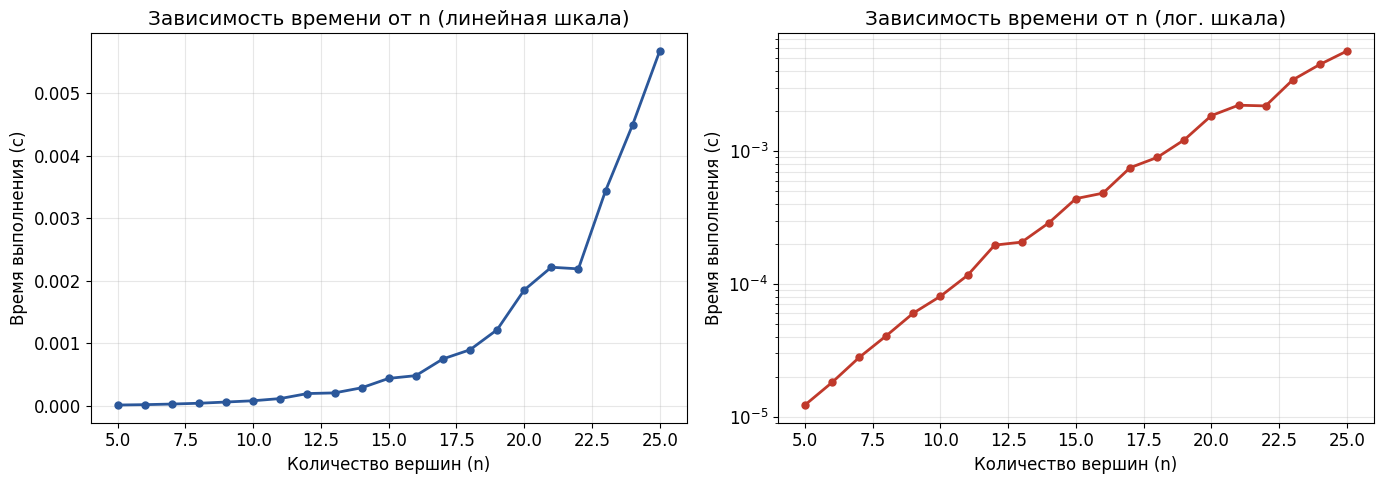

In [2]:
def generate_random_graph(n, edge_prob=0.3):
    """Генерирует случайный граф с n вершинами и вероятностью ребра edge_prob"""
    edges = []
    for i in range(1, n + 1):
        for j in range(i + 1, n + 1):
            if random.random() < edge_prob:
                edges.append((i, j))
    return edges

def measure_time(n, edge_prob=0.3, repeats=5):
    """Замеряет среднее время выполнения алгоритма для графа с n вершинами"""
    times_list = []
    for _ in range(repeats):
        edges = generate_random_graph(n, edge_prob)
        start = time.perf_counter()
        find_max_independent_set(n, edges)
        end = time.perf_counter()
        times_list.append(end - start)
    return times_list

# Диапазон вершин для замера (не слишком большой — алгоритм O(2^n))
vertex_counts = list(range(5, 26))
repeats = 10

all_times = {}      # n -> список времён (для каждого запуска)
mean_times = []     # среднее время для каждого n

print("\n" + "=" * 60)
print("Замер времени выполнения")
print("=" * 60)

for n in vertex_counts:
    t_list = measure_time(n, edge_prob=0.3, repeats=repeats)
    all_times[n] = t_list
    avg = np.mean(t_list)
    mean_times.append(avg)
    print(f"n = {n:3d}  |  среднее время: {avg:.6f} с  |  макс: {max(t_list):.6f} с")

# ═══════════════════════════════════════════════════════════════
# 3. ПОСТРОЕНИЕ ГРАФИКА ЗАВИСИМОСТИ ВРЕМЕНИ ОТ n
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Линейная шкала ---
axes[0].plot(vertex_counts, mean_times, 'o-', color='#2B579A', linewidth=2, markersize=5)
axes[0].set_xlabel('Количество вершин (n)')
axes[0].set_ylabel('Время выполнения (с)')
axes[0].set_title('Зависимость времени от n (линейная шкала)')
axes[0].grid(True, alpha=0.3)

# --- Логарифмическая шкала ---
axes[1].plot(vertex_counts, mean_times, 'o-', color='#C0392B', linewidth=2, markersize=5)
axes[1].set_xlabel('Количество вершин (n)')
axes[1].set_ylabel('Время выполнения (с)')
axes[1].set_title('Зависимость времени от n (лог. шкала)')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

In [4]:
test_n = max(vertex_counts)
times = np.array(all_times[test_n])

# Если мало данных — делаем дополнительные замеры
if len(times) < 30:
    print(f"\nДополнительные замеры для n={test_n}...")
    extra = measure_time(test_n, edge_prob=0.3, repeats=50)
    times = np.array(extra)

print(f"\nВсего замеров для n = {test_n}: {len(times)}")
print(f"Среднее: {np.mean(times):.6f} с")
print(f"СКО:     {np.std(times):.6f} с")

# ── 4а. Гипотеза через Колмогорова-Смирнова ──────────────────

print("\n" + "=" * 60)
print("ГИПОТЕЗА ЧЕРЕЗ КОЛМОГОРОВА-СМИРНОВА")
print("=" * 60)

# Нормальное распределение
mu, sigma = stats.norm.fit(times)
stat_ks, p_ks = stats.kstest(times, 'norm', args=(mu, sigma))
print(f"\nНормальное распределение:")
print(f"  mu = {mu:.6f}, sigma = {sigma:.6f}")
print(f"  p-value: {p_ks:.4f}")
print(f"  {'Подходит' if p_ks > 0.05 else 'Не подходит'}")

# Логнормальное распределение
shape, loc, scale = stats.lognorm.fit(times)
stat_ks_ln, p_ks_ln = stats.kstest(times, 'lognorm', args=(shape, loc, scale))
print(f"\nЛогнормальное распределение:")
print(f"  shape = {shape:.4f}, loc = {loc:.6f}, scale = {scale:.6f}")
print(f"  p-value: {p_ks_ln:.4f}")
print(f"  {'Подходит' if p_ks_ln > 0.05 else 'Не подходит'}")

# Экспоненциальное распределение
loc_exp, scale_exp = stats.expon.fit(times)
stat_ks_exp, p_ks_exp = stats.kstest(times, 'expon', args=(loc_exp, scale_exp))
print(f"\nЭкспоненциальное распределение:")
print(f"  loc = {loc_exp:.6f}, scale = {scale_exp:.6f}")
print(f"  p-value: {p_ks_exp:.4f}")
print(f"  {'Подходит' if p_ks_exp > 0.05 else 'Не подходит'}")


Дополнительные замеры для n=25...

Всего замеров для n = 25: 50
Среднее: 0.015102 с
СКО:     0.009537 с

ГИПОТЕЗА ЧЕРЕЗ КОЛМОГОРОВА-СМИРНОВА

Нормальное распределение:
  mu = 0.015102, sigma = 0.009537
  p-value: 0.1095
  Подходит

Логнормальное распределение:
  shape = 1.1024, loc = 0.004810, scale = 0.006206
  p-value: 0.8194
  Подходит

Экспоненциальное распределение:
  loc = 0.005274, scale = 0.009828
  p-value: 0.9061
  Подходит


In [6]:
def chi2_test(times, dist_name, dist_params, label):
    """Критерий хи-квадрат для заданного распределения"""
    observed, bins = np.histogram(times, bins='auto', density=False)

    if dist_name == 'norm':
        cdf_func = lambda x: stats.norm.cdf(x, *dist_params)
    elif dist_name == 'lognorm':
        cdf_func = lambda x: stats.lognorm.cdf(x, *dist_params)
    elif dist_name == 'expon':
        cdf_func = lambda x: stats.expon.cdf(x, *dist_params)

    expected = cdf_func(bins[1:]) - cdf_func(bins[:-1])  # вероятности
    expected = expected * len(times)  # переводим в частоты

    # убираем интервалы с частотой < 5
    mask = expected >= 5
    if mask.sum() < 2:
        # если слишком мало интервалов, объединяем
        print(f"\n{label}:")
        print(f"  Недостаточно интервалов с ожидаемой частотой >= 5")
        return

    observed = observed[mask]
    expected = expected[mask]

    # нормализуем
    expected = expected * observed.sum() / expected.sum()

    chi2_stat, p_value = stats.chisquare(observed, expected)

    print(f"\n{label}:")
    print(f"  chi2 = {chi2_stat:.4f}")
    print(f"  p-value = {p_value:.4f}")
    print(f"  {'Подходит' if p_value > 0.05 else 'Не подходит'}")

chi2_test(times, 'norm', (mu, sigma), "Нормальное распределение")
chi2_test(times, 'lognorm', (shape, loc, scale), "Логнормальное распределение")
chi2_test(times, 'expon', (loc_exp, scale_exp), "Экспоненциальное распределение")



Нормальное распределение:
  chi2 = 22.8852
  p-value = 0.0000
  Не подходит

Логнормальное распределение:
  chi2 = 1.4657
  p-value = 0.4805
  Подходит

Экспоненциальное распределение:
  chi2 = 1.6591
  p-value = 0.4362
  Подходит
